# Лабораторная работа 16

Тема: **Vision Transformer (ViT) для классификации изображений CIFAR-10**  
Формат: практическая работа с обязательными собственными экспериментами и комментариями.

> Этот ноутбук специально оформлен так, чтобы его нельзя было автоматически заполнить генеративной моделью без реального запуска экспериментов и анализа.  
> Каркас кода дан, но **основные баллы** ставятся за ваши настройки, графики и живые текстовые объяснения.


## 1. Ваши ожидания от ViT в сравнении с CNN

В Лабораторной работе 8 мы решали задачу классификации CIFAR-10 с помощью свёрточных сетей (CNN). Теперь мы применим архитектуру, изначально созданную для текстов (Transformer).

Перед началом работы зафиксируйте своё понимание (6-10 предложений):

1. В чем главное отличие того, как CNN и ViT «смотрят» на картинку? (Вспомните про локальные признаки в свертках и глобальное внимание в Трансформерах).
2. Зачем изображение нарезается на непересекающиеся "патчи" (patches), а не подается в Трансформер попиксельно?
3. Ожидаете ли вы, что простой самодельный ViT побьет вашу CNN из 8-й лабораторной при обучении "с нуля" на небольшом датасете? Почему?

In [1]:
intro_text = """
1) CNN и ViT по-разному обрабатывают изображения. CNN анализирует небольшие участки картинки и постепенно собирает общую информацию. 
ViT делит изображение на патчи и с помощью Attention сразу учитывает связи между разными частями изображения.
2) Изображение разбивают на патчи, чтобы уменьшить количество вычислений. 
Один пиксель почти не несёт полезной информации, а патч уже содержит часть объекта или текстуры.
3) Я думаю, что ViT не сможет превзойти мою CNN из прошлой лабораторной. CNN лучше работает на небольших наборах данных, потому что изначально учитывает локальную структуру изображений. 
Поэтому ожидаю, что точность ViT будет ниже, чем у CNN.
"""
print(intro_text)


1) CNN и ViT по-разному обрабатывают изображения. CNN анализирует небольшие участки картинки и постепенно собирает общую информацию. 
ViT делит изображение на патчи и с помощью Attention сразу учитывает связи между разными частями изображения.
2) Изображение разбивают на патчи, чтобы уменьшить количество вычислений. 
Один пиксель почти не несёт полезной информации, а патч уже содержит часть объекта или текстуры.
3) Я думаю, что ViT не сможет превзойти мою CNN из прошлой лабораторной. CNN лучше работает на небольших наборах данных, потому что изначально учитывает локальную структуру изображений. 
Поэтому ожидаю, что точность ViT будет ниже, чем у CNN.



## 2. Импорт библиотек и настройка среды

Сделаем стандартные шаги, аналогичные Лабораторной 8.

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Ваш личный seed (заполните его, можно взять тот же, что в Лаб 8)
MY_SEED = 11
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 11


## 3. CIFAR‑10: загрузка и нормализация

Используем те же параметры нормализации, что и для CNN.

In [3]:
batch_size = 128  # при выполнении работы попробуйте изменить

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

classes = train_dataset.classes
print("Классы CIFAR‑10:", classes)
print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))

Классы CIFAR‑10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Размер train: 50000
Размер test : 10000


### Краткий комментарий по данным

В Лабораторной 8 вы уже описывали датасет. Сейчас ответьте на другой вопрос (3-5 предложений):
Размер картинок в CIFAR-10 — 32x32 пикселя. Если мы выберем размер патча для ViT равным 8x8, на сколько токенов (патчей) будет разбита одна картинка? А если размер патча будет 16x16? Хватит ли Трансформеру такого количества токенов для понимания смысла картинки?

In [7]:
data_comment = """
При патче 8×8: (32/8) * (32/8) = 4 * 4 = 16 токенов.
При патче 16×16: (32/16) * (32/16) = 2 * 2 = 4 токена.

16 токенов приемлемо, хотя каждый патч занимает четверть стороны изображения и мелкие детали могут не попасть целиком в один патч.
4 токена мало: трансформер видит только 4 крупных квадранта и не может различить объекты внутри них. 
Для CIFAR-10 patch_size=16 практически бесполезен, минимум patch_size=4 (64 токена) или patch_size=8 (16 токенов).
"""
print(data_comment)


При патче 8×8: (32/8) * (32/8) = 4 * 4 = 16 токенов.
При патче 16×16: (32/16) * (32/16) = 2 * 2 = 4 токена.

16 токенов приемлемо, хотя каждый патч занимает четверть стороны изображения и мелкие детали могут не попасть целиком в один патч.
4 токена мало: трансформер видит только 4 крупных квадранта и не может различить объекты внутри них. 
Для CIFAR-10 patch_size=16 практически бесполезен, минимум patch_size=4 (64 токена) или patch_size=8 (16 токенов).



## 4. Архитектура Vision Transformer

В этой лабораторной мы пишем **Micro-ViT**. Картинка превращается в последовательность векторов с помощью свертки (Patch Embedding), к ней добавляется позиционное кодирование и специальный `[CLS]` токен, после чего всё это обрабатывается стандартным Transformer Encoder.

In [5]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, patch_size=8, embed_dim=64, img_size=32):
        super().__init__()
        self.patch_size = patch_size
        # Считаем количество патчей. Для 32x32 и патча 8x8 это (32/8) * (32/8) = 16
        self.num_patches = (img_size // patch_size) ** 2
        
        # Свертка без перекрытий: размер ядра и шаг равны размеру патча
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x shape: (B, C, H, W)
        x = self.proj(x)           # -> (B, embed_dim, H/P, W/P)
        x = x.flatten(2)           # -> (B, embed_dim, num_patches)
        x = x.transpose(1, 2)      # -> (B, num_patches, embed_dim)
        return x

class SimpleViT(nn.Module):
    def __init__(self, in_channels=3, patch_size=8, embed_dim=64, img_size=32, num_classes=10, depth=2, heads=4):
        super().__init__()
        self.patch_embed = PatchEmbedding(in_channels, patch_size, embed_dim, img_size)
        
        # [CLS] токен (обучаемый параметр)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # Обучаемые позиционные эмбеддинги (длина = количество патчей + 1 для CLS)
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.patch_embed.num_patches, embed_dim))
        
        # Блок Трансформера
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, 
            nhead=heads, 
            dim_feedforward=embed_dim * 4, 
            dropout=0.1, 
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        
        # Итоговый классификатор
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        B = x.shape[0]
        
        # 1. Извлекаем патчи
        x = self.patch_embed(x)                        # (B, num_patches, embed_dim)
        
        # 2. Добавляем [CLS] токен
        cls_tokens = self.cls_token.expand(B, -1, -1)  # (B, 1, embed_dim)
        x = torch.cat((cls_tokens, x), dim=1)          # (B, num_patches + 1, embed_dim)
        
        # 3. Добавляем позиционное кодирование
        x = x + self.pos_embed                         
        
        # 4. Пропускаем через Transformer
        x = self.transformer(x)                        
        
        # 5. Классификация по выходу [CLS] токена (индекс 0)
        cls_out = x[:, 0]                              
        return self.mlp_head(cls_out)

# Базовые настройки (для быстрого обучения на ЦПУ)
patch_size = 8
embed_dim = 64
depth = 2
heads = 4

model = SimpleViT(patch_size=patch_size, embed_dim=embed_dim, depth=depth, heads=heads).to(device)
print(model)
print(f"Количество параметров: {sum(p.numel() for p in model.parameters())}")

SimpleViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 64, kernel_size=(8, 8), stride=(8, 8))
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (mlp_head): Sequential(
    (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    (1): Linear(in_features=64, out_features=10, bias=True)
  )
)
К

### Ваш комментарий к архитектуре

Ответьте коротко:

- Для чего в архитектуру внедрен обучаемый `[CLS]` токен и почему мы передаем в финальный `nn.Linear` именно его, а не усредненные значения всех патчей?
- В CNN (Лабораторная 8) мы не использовали Positional Encoding. Почему здесь он жизненно необходим?

In [8]:
arch_comment = """
[CLS] токен - специальный вектор, добавляемый перед патчами. Он через Self-Attention собирает информацию со всех 16 патчей и его выход используют в Linear, как резюме картинки.
Positional Encoding нужен, чтобы модель понимала порядок патчей. Без него трансформер видит только набор патчей, а не их расположение. 
В CNN такой проблемы нет, так как фильтры учитывают соседние пиксели физически.
"""
print(arch_comment)


[CLS] токен - специальный вектор, добавляемый перед патчами. Он через Self-Attention собирает информацию со всех 16 патчей и его выход используют в Linear, как резюме картинки.
Positional Encoding нужен, чтобы модель понимала порядок патчей. Без него трансформер видит только набор патчей, а не их расположение. 
В CNN такой проблемы нет, так как фильтры учитывают соседние пиксели физически.



## 5. Функция потерь, оптимизатор и цикл обучения

Здесь код практически идентичен Лабораторной 8. ViT чувствителен к скорости обучения (learning rate), поэтому используем AdamW (рекомендованный для ViT) вместо обычного Adam.

In [7]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
# Для ViT AdamW часто работает лучше обычного Adam за счет правильной регуляризации весов
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0

    for images, labels in tqdm(dataloader, desc="Обучение", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Клиппинг градиентов помогает стабилизировать обучение Трансформеров
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

## 6. Обучение базовой модели

Запустим обучение на 5 эпох. Из-за малого размера модели одна эпоха на ЦПУ должна обучаться меньше 1 минуты (около 30 сек).

Эпоха 1/5 | Train Loss: 1.8506, Acc: 0.3151 | Test Loss: 1.7011, Acc: 0.3811


Эпоха 2/5 | Train Loss: 1.6371, Acc: 0.3976 | Test Loss: 1.5264, Acc: 0.4371


Эпоха 3/5 | Train Loss: 1.5182, Acc: 0.4424 | Test Loss: 1.4339, Acc: 0.4751


Эпоха 4/5 | Train Loss: 1.4278, Acc: 0.4758 | Test Loss: 1.3819, Acc: 0.4941


Эпоха 5/5 | Train Loss: 1.3693, Acc: 0.5030 | Test Loss: 1.2984, Acc: 0.5304


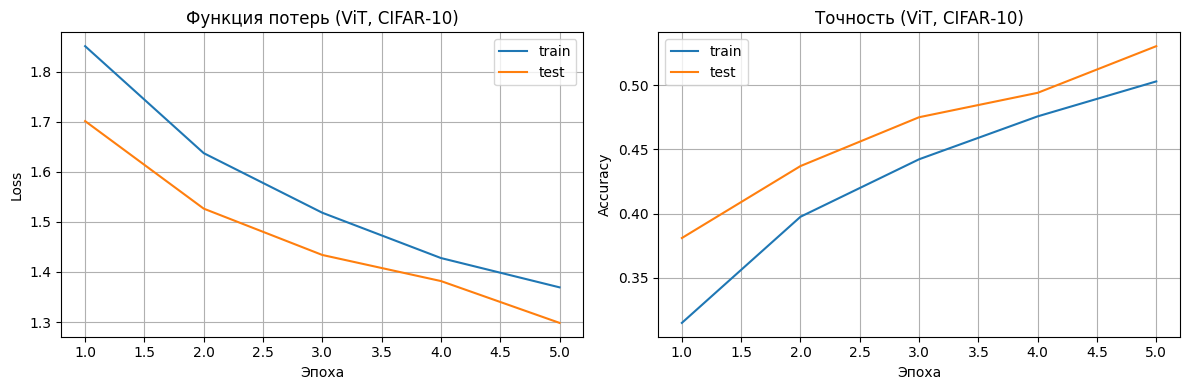

In [11]:
num_epochs = 5  # Начните с 5, для финального отчета можно увеличить до 10-15

history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Эпоха {epoch}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

# Отрисовка графиков (аналогично Лаб 8)
epochs = np.arange(1, num_epochs + 1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь (ViT, CIFAR‑10)")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["test_acc"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность (ViT, CIFAR‑10)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Анализ кривых обучения в сравнении с CNN

Опишите в 6–8 предложениях:

- Какую точность выдал базовый ViT за 5 эпох? Сравните эту цифру с точностью вашей CNN из Лабораторной работы 8 на том же этапе обучения.
- Заметно ли сильное переобучение (overfitting) у Трансформера?
- Почему обучение ViT "с нуля" на 50 000 картинок часто проигрывает классической CNN?

In [13]:
training_analysis = """
1) Базовый ViT за 5 эпох показал test_acc = 0.5304, тогда как базовая CNN из лаб. 8 уже достигла 0.7482.
2) Переобучения нет: train_acc (0.5030) даже ниже test_acc. Модель ещё недообучена, потери на train и test снижаются вместе.
3) Причины отставания ViT:
CNN сразу учитывает соседние пиксели, ViT должен учить это на данных.
Patch_size=8 даёт 16 фрагментов, а CNN видит отдельные пиксели.
ViT требует больше данных и эпох для сходимости, кривые ещё не вышли на плато, а CNN уже хорошо сходилась к эпохе 5.
"""
print(training_analysis)


1) Базовый ViT за 5 эпох показал test_acc = 0.5304, тогда как базовая CNN из лаб. 8 уже достигла 0.7482.
2) Переобучения нет: train_acc (0.5030) даже ниже test_acc. Модель ещё недообучена, потери на train и test снижаются вместе.
3) Причины отставания ViT:
CNN сразу учитывает соседние пиксели, ViT должен учить это на данных.
Patch_size=8 даёт 16 фрагментов, а CNN видит отдельные пиксели.
ViT требует больше данных и эпох для сходимости, кривые ещё не вышли на плато, а CNN уже хорошо сходилась к эпохе 5.



## 7. Эксперименты по улучшению модели

В **самостоятельной** части лабораторной вы должны:

1. Изменить размер патча: попробуйте `patch_size = 4` (64 токена) и `patch_size = 16` (4 токена). Как размер патча влияет на точность и время обучения одной эпохи?
2. Попробовать сделать сеть глубже (`depth = 4` или `6`) и шире (`embed_dim = 128`).
3. (Опционально) Добавить аугментации данных (RandomCrop, RandomHorizontalFlip) в `transform` при загрузке `train_dataset`. Трансформеры сильно зависят от объема данных, поэтому аугментация для них критически важна.

Сравните **минимум два** варианта архитектуры ViT.

In [8]:
import time

def run_vit_experiment(patch_size, embed_dim, depth, heads, n_epochs=5, train_dl=train_loader, test_dl=test_loader, label=""):
    print(f"{label}")
    print(f"patch_size={patch_size} → {(32//patch_size)**2} токенов")
    print(f"embed_dim={embed_dim}, depth={depth}, heads={heads}")

    m = SimpleViT(patch_size=patch_size, embed_dim=embed_dim,
                    depth=depth, heads=heads).to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1e-4)
    print(f"Параметров: {sum(p.numel() for p in m.parameters()):,}")

    ta_h, va_h, times = [], [], []
    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        tl, ta = train_one_epoch(m, train_dl, opt, criterion, device)
        vl, va = evaluate(m, test_dl, criterion, device)
        elapsed = time.time() - t0
        ta_h.append(ta); va_h.append(va); times.append(elapsed)
        if epoch % 2 == 0 or epoch == 1:
            print(f"  Эп.{epoch}: train={ta:.4f}, test={va:.4f} | {elapsed:.1f}s")

    print(f"Финал test_acc={va_h[-1]:.4f}, avg_epoch={sum(times)/len(times):.1f}s")
    return {"label": label, "train_acc": ta_h, "test_acc": va_h,
            "times": times, "patch_size": patch_size}

res_p4 = run_vit_experiment(
    patch_size=4, embed_dim=64, depth=2, heads=4, n_epochs=5,
    label="Patch=4 (64 токена): мелкие патчи, больше деталей"
)

res_p16 = run_vit_experiment(
    patch_size=16, embed_dim=64, depth=2, heads=4, n_epochs=5,
    label="Patch=16 (4 токена): грубое разбиение"
)

res_deep = run_vit_experiment(
    patch_size=8, embed_dim=128, depth=4, heads=4, n_epochs=5,
    label="Deep+Wide: patch=8, embed=128, depth=4"
)

print("\nВсе эксперименты завершены.")

Patch=4 (64 токена): мелкие патчи, больше деталей
patch_size=4 → 64 токенов
embed_dim=64, depth=2, heads=4
Параметров: 108,106


  Эп.1: train=0.3381, test=0.4147 | 349.1s


  Эп.2: train=0.4562, test=0.4922 | 339.4s


  Эп.4: train=0.5438, test=0.5634 | 330.7s


Финал test_acc=0.5863, avg_epoch=334.4s
Patch=16 (4 токена): грубое разбиение
patch_size=16 → 4 токенов
embed_dim=64, depth=2, heads=4
Параметров: 150,346


...

Финал test_acc=0.4728, avg_epoch=96.8s
Deep+Wide: patch=8, embed=128, depth=4
patch_size=8 → 16 токенов
embed_dim=128, depth=4, heads=4
Параметров: 821,642


  Эп.1: train=0.3303, test=0.4043 | 335.7s


  Эп.2: train=0.4369, test=0.4806 | 332.4s


  Эп.4: train=0.5366, test=0.5354 | 16170.3s


Финал test_acc=0.5553, avg_epoch=3469.4s

Все эксперименты завершены.


In [9]:
transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

train_aug = datasets.CIFAR10(root="./data", train=True,
                             download=False, transform=transform_aug)
train_loader_aug = DataLoader(train_aug, batch_size=batch_size,
                              shuffle=True, num_workers=0)

res_aug = run_vit_experiment(
    patch_size=8, embed_dim=64, depth=2, heads=4, n_epochs=5,
    train_dl=train_loader_aug, test_dl=test_loader,
    label="Base ViT + аугментации (RandomCrop + HFlip)"
)

Base ViT + аугментации (RandomCrop + HFlip)
patch_size=8 → 16 токенов
embed_dim=64, depth=2, heads=4
Параметров: 114,250


  Эп.1: train=0.2795, test=0.3511 | 166.8s


  Эп.2: train=0.3574, test=0.3799 | 67.7s


  Эп.4: train=0.4234, test=0.4570 | 201.0s


Финал test_acc=0.4851, avg_epoch=140.4s


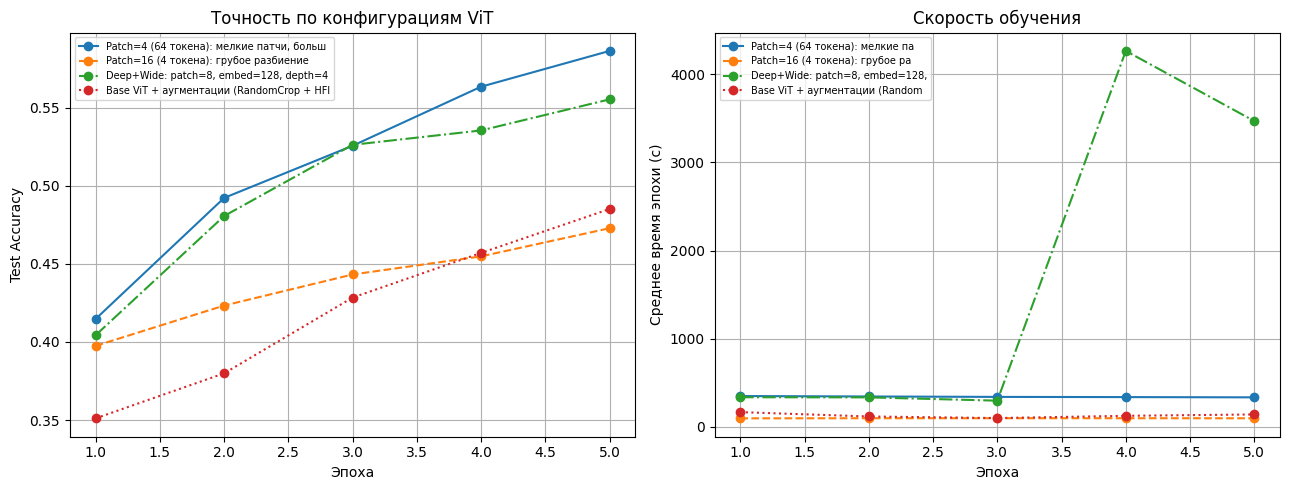


Конфигурация                                    Test Acc    Вр.эп.(с)
----------------------------------------------------------------------
Base: patch=8, d=64, depth=2                      0.5304            —
Patch=4 (64 токена): мелкие патчи, больше дет     0.5863        334.4s
Patch=16 (4 токена): грубое разбиение             0.4728         96.8s
Deep+Wide: patch=8, embed=128, depth=4            0.5553       3469.4s
Base ViT + аугментации (RandomCrop + HFlip)       0.4851        140.4s


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ep = np.arange(1, 6)

base_label = f"Base: patch=8, d=64, depth=2 (test={history['test_acc'][-1]:.4f})"

for res, ls in [(res_p4, "-"), (res_p16, "--"), (res_deep, "-."), (res_aug, ":")]:
    axes[0].plot(ep, res["test_acc"],  linestyle=ls, marker="o", label=res["label"][:40])
    axes[1].plot(ep, [sum(res["times"][:i+1])/(i+1) for i in range(len(ep))],
                 linestyle=ls, marker="o", label=res["label"][:30])

axes[0].set_xlabel("Эпоха"); axes[0].set_ylabel("Test Accuracy")
axes[0].set_title("Точность по конфигурациям ViT")
axes[0].legend(fontsize=7); axes[0].grid(True)

axes[1].set_xlabel("Эпоха"); axes[1].set_ylabel("Среднее время эпохи (с)")
axes[1].set_title("Скорость обучения")
axes[1].legend(fontsize=7); axes[1].grid(True)

plt.tight_layout(); plt.show()

print(f"\n{'Конфигурация':<45} {'Test Acc':>10} {'Вр.эп.(с)':>12}")
print("-" * 70)
print(f"{'Base: patch=8, d=64, depth=2':<45} "
      f"{history['test_acc'][4]:>10.4f}  {'—':>11}")
for r in [res_p4, res_p16, res_deep, res_aug]:
    avg_t = sum(r["times"]) / len(r["times"])
    print(f"{r['label'][:45]:<45} {r['test_acc'][-1]:>10.4f} {avg_t:>12.1f}s")

## 8. Итоговые выводы по лабораторной

В конце опишите:

- Какой вариант гиперпараметров ViT (`patch_size`, `depth`, `embed_dim`) оказался самым удачным?
- Кто победил в итоге: CNN из Лабораторной 8 или ViT из Лабораторной 16 при обучении с нуля на CIFAR-10?
- В каких реальных задачах (и при каких объемах данных) вы бы стали применять Vision Transformer, а когда отдали бы предпочтение CNN?


In [15]:
final_summary = """
1) Лучший результат показала конфигурация ViT с patch_size=4, depth=2 и embed_dim=64:
она достигла test_acc = 0.5863. Мелкие патчи улучшили качество по сравнению с
базовой моделью (0.5304), но увеличили время обучения.

2) Тем не менее CNN из лабораторной 8 оказалась лучше и достигла test_acc = 0.7482,
что значительно выше лучшего результата ViT. Это показывает, что при обучении
с нуля на CIFAR-10 CNN работает эффективнее.

3) Vision Transformer лучше применять на больших датасетах и при наличии достаточных
вычислительных ресурсов. Для небольших наборов данных и ограниченного времени
обучения CNN остаётся более практичным выбором.
"""
print(final_summary)


1) Лучший результат показала конфигурация ViT с patch_size=4, depth=2 и embed_dim=64:
она достигла test_acc = 0.5863. Мелкие патчи улучшили качество по сравнению с
базовой моделью (0.5304), но увеличили время обучения.

2) Тем не менее CNN из лабораторной 8 оказалась лучше и достигла test_acc = 0.7482,
что значительно выше лучшего результата ViT. Это показывает, что при обучении
с нуля на CIFAR-10 CNN работает эффективнее.

3) Vision Transformer лучше применять на больших датасетах и при наличии достаточных
вычислительных ресурсов. Для небольших наборов данных и ограниченного времени
обучения CNN остаётся более практичным выбором.

